# Linear regression with no tools
We sow in the last .ipynb how we can train a model using the least squares, but in all the calculations that we needed we used tools, like _pandas_ for CVS processing, _sklearn_ for data processing and for the model. So here we will do it all row (dogie style)

---

First we need make our own _dataframe_ witch will just be a map

In [1]:
# we know that the firs line in the cvs has the names of the columns
keys = ['Happiness.Score', 'Family', 'Freedom', 'Economy..GDP.per.Capita.']

# the name of the column and the index
key_map:dict[int, str] = {}

# the first line
with open('data/v1_world-happiness-report-2017.csv', newline='') as csvfile:
    for index, column_name in enumerate(csvfile.readline().split(',')):
        if column_name in keys:
            key_map[index] = column_name

print(key_map)

{2: 'Happiness.Score', 5: 'Economy..GDP.per.Capita.', 6: 'Family', 8: 'Freedom'}


In [2]:
df: dict[str, list[float]] = {
    keys[0] : [],
    keys[1] : [],
    keys[2] : [],
    keys[3] : [],
}

with open('data/v1_world-happiness-report-2017.csv', newline='') as csvfile:
    csvfile.readline()  # skip header (just ONE line)
    for line in csvfile.readlines():
        for index, row in enumerate(line.split(',')):
            if index in key_map.keys():
                df[key_map[index]].append(float(row))

```python
print(1.551674843 in df['Family'])
print(set(df['Family']))
# True
# {1.510041952, 1.551674843}
```
What are this number, you may ask? LOOK AT HIS FUCKERY
```
"Hong Kong S.A.R., China",71,5.472000122,5.549594173,5.394406071,1.551674843,1.510041952,0.943062425,0.490968645,0.374465793,0.293933749,0.554633141
```
Do you see it??? Theirs a COMMA it the name and because of this we have a ghost number that shouldn't be in the dataframe. There might be a smart why to fix this and have a regex to account for quotes or to go through the line character by character and have an easy logic for this... BUT NO. IT AIN'T THAT DEEP, I will just remove the comma... later I might change this but rn I just want to finish

---
### Quick plot

Now that we've done this, it's time to plot the data (this will be the only package we will use).

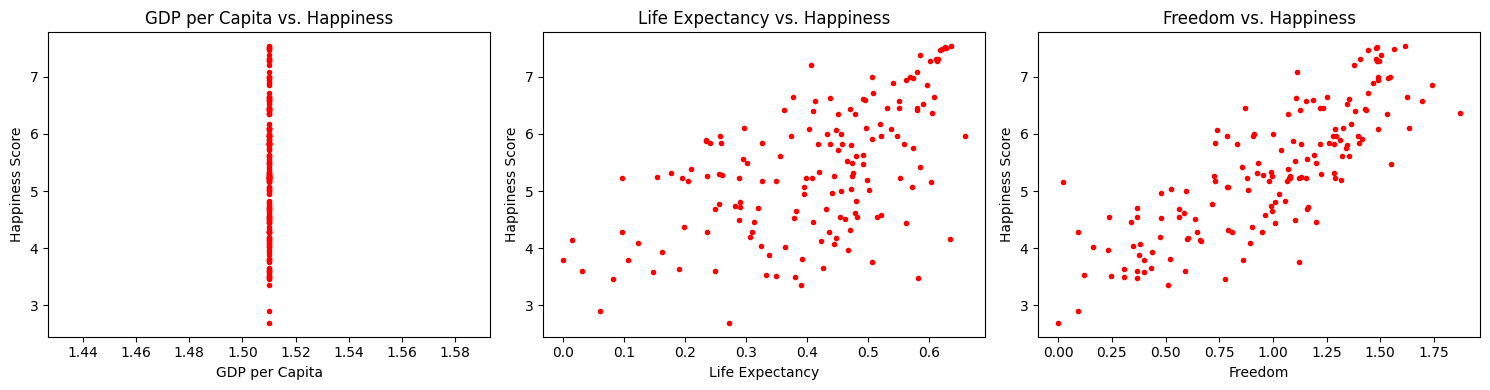

In [3]:
import matplotlib.pyplot as plt

target = 'Happiness.Score'
features = ['Family', 'Freedom', 'Economy..GDP.per.Capita.']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feature, label in zip(axes, features, ['GDP per Capita', 'Life Expectancy', 'Freedom']):
    ax.plot(df[feature], df[target], 'ro', markersize=3)
    ax.set_xlabel(label)
    ax.set_ylabel('Happiness Score')
    ax.set_title(f'{label} vs. Happiness')

plt.tight_layout()
plt.show()

### Normalization
The data looks ok, so now let's normalize it!

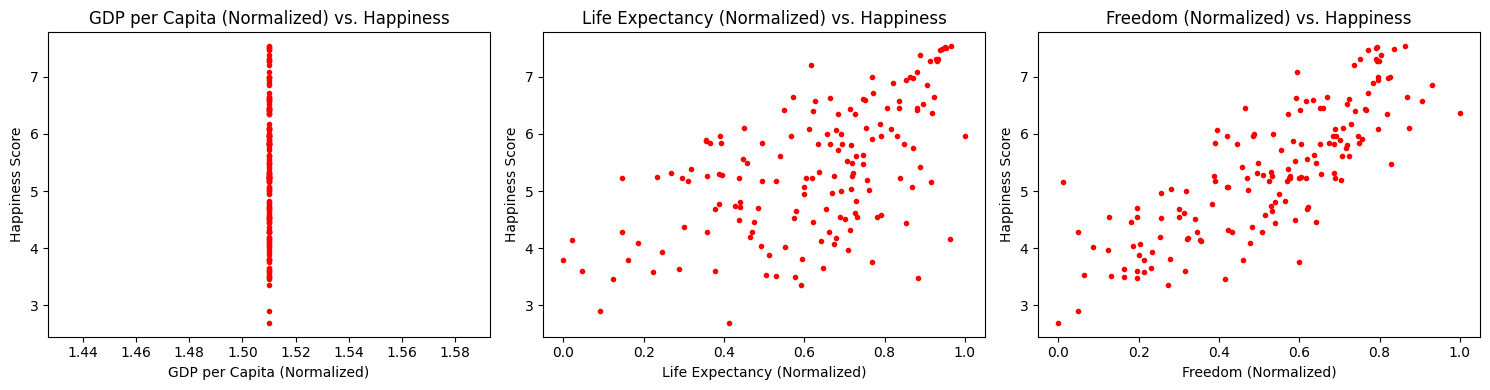

In [4]:
def min_max_normalization(df, column_name):
    min_val = min(df[column_name])
    max_val = max(df[column_name])
    if min_val == max_val:
        print(f'Warning: column {column_name} has zero variance, skipping normalization.')
        df[column_name + "_normalized"] = df[column_name]
        return
    df[column_name + "_normalized"] = [(val - min_val) / (max_val - min_val) for val in df[column_name]]

for feature in features:
    min_max_normalization(df, feature)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feature, label in zip(axes, features, ['GDP per Capita (Normalized)', 'Life Expectancy (Normalized)', 'Freedom (Normalized)']):
    ax.plot(df[feature + "_normalized"], df[target], 'ro', markersize=3)
    ax.set_xlabel(label)
    ax.set_ylabel('Happiness Score')
    ax.set_title(f'{label} vs. Happiness')

plt.tight_layout()
plt.show()

### Train Test Spliter
Now we need to split our data set so that we have with what to train and after to test. For this we will use [Fisher-Yates shuffle](https://www.geeksforgeeks.org/dsa/shuffle-a-given-array-using-fisher-yates-shuffle-algorithm/)

In [5]:
def train_test_spliter(X:list[list], Y:list[int], test_size=0.2, random_state=1):
    # we know that evey list in X and Y have the same length
    n = len(Y)
    data = list(zip(X, Y))

    # Fisher-Yates shuffle
    seed = random_state
    for i in range(n - 1, 0, -1):
        seed = (seed * 12345 + 12345)
        j = seed % (i + 1)
        data[i], data[j] = data[j], data[i]

    # unzip back
    X_shuffled, Y_shuffled = zip(*data)
    X_shuffled, Y_shuffled = list(X_shuffled), list(Y_shuffled)

    split_index = int(n * (1 - test_size))

    X_train = X_shuffled[:split_index]
    X_test  = X_shuffled[split_index:]
    Y_train = Y_shuffled[:split_index]
    Y_test  = Y_shuffled[split_index:]

    return X_train, X_test, Y_train, Y_test

### Linear Regressor, the hardest part
>[GeeksForGeeks](https://www.geeksforgeeks.org/machine-learning/ml-linear-regression/)

To find the best-fit line, we use a method called Least Squares. The idea behind this method is to minimize the sum of squared differences between the actual values (data points) and the predicted values from the line. These differences are called residuals.
+ For m features we have an... not so easy to code formula
$$ w = (X^TX)^{-1}X^TY $$
+ For just one feature, we have $f(x,w) = w_0 + x * w_1$
$$ w_0 = \frac{\sum y - w_1\sum x}{n} $$
$$ w_1 =  \frac{n\sum xy - (\sum x)(\sum y)}{n\sum x^2 - (\sum x)^2} $$

In [6]:
class LinearRegression:
    def __init__(self):
        self.intercept_ = None
        self.coef_ = None

    def _matrix_transpose(self, M):
        return [[M[j][i] for j in range(len(M))] for i in range(len(M[0]))]

    def _matrix_inverse(self, M):
        # hardcoded for 3x3 using Cramer's rule
        a,b,c = M[0]; d,e,f = M[1]; g,h,i = M[2]

        det = a*(e*i - f*h) - b*(d*i - f*g) + c*(d*h - e*g)
        assert det != 0, "Matrix is not invertible"

        return [
            [ (e*i - f*h)/det, -(b*i - c*h)/det,  (b*f - c*e)/det],
            [-(d*i - f*g)/det,  (a*i - c*g)/det, -(a*f - c*d)/det],
            [ (d*h - e*g)/det, -(a*h - b*g)/det,  (a*e - b*d)/det],
        ]

    def _matrix_multiplication(self, A, B):
        # B is a flat list (Y vector)
        if isinstance(B[0], list):
            cols_B = len(B[0])
            return [[sum(A[i][k] * B[k][j] for k in range(len(B))) for j in range(cols_B)] for i in range(len(A))]
        else:
            return [sum(A[i][k] * B[k] for k in range(len(B))) for i in range(len(A))]

    def fit_one_features(self, X:list[int], Y:list[int]):
        sumX = sum(X)
        sumY = sum(Y)
        sumXY = sum([x * y for x, y in zip(X, Y)])
        sumX2 = sum([x ** 2 for x in X])
        n = len(X)
        w_1 = (n * sumXY - sumX * sumY) / (n * sumX2 - sumX ** 2)
        w_0 = (sumY - w_1 * sumX) / n

        self.intercept_ = w_0
        self.coef_ = [w_1]

    def fit_two_feature(self, X:list[list], Y:list[int]):
        X_matrix = [[1.0] + list(_row) for _row in X]
        Y_matrix = [[y] for y in Y]

        XT_matrix = self._matrix_transpose(X_matrix)

        w = self._matrix_multiplication(
                self._matrix_multiplication(
                    self._matrix_inverse(
                        self._matrix_multiplication(
                            XT_matrix,
                            X_matrix
                        )
                    ),
                    XT_matrix
                ),
                Y_matrix
            )
        self.intercept_ = w[0][0]
        self.coef_ = [w[1][0], w[2][0]]

    def predict(self, X:list) -> list[float]:
        if isinstance(X[0], (tuple, list)):
            return [self.intercept_ + self.coef_[0] * X[i][0] + self.coef_[1] * X[i][1] for i in range(len(X))]
        else:
            return [self.intercept_ + self.coef_[0] * X[i] for i in range(len(X))]

### Error
Industry standard errors: <br>
+ the absolute difference ($L_1$): $$ Error = \frac{1}{n} * \sum_{i=1}^{n}|y^i - y^i_c| = Mean Absolut Error (MAE) $$
+ the square difference ($L_2$): $$ Error = \sqrt{ \frac{1}{n} * \sum_{i=1}^{n}(y^i - y^i_c)^2} = Root Mean Square Error (RMSE) $$

In [7]:
def mean_absolut_error(y_true, y_pred):
    error = 0
    for y, y_c in zip(y_true, y_pred):
        error += abs(y - y_c)
    return error / len(y_true)

def root_mean_squared_error(y_true, y_pred):
    error = 0
    for y, y_c in zip(y_true, y_pred):
        error += (y - y_c) ** 2
    return (error / len(y_true)) ** 0.5

### Training time babyyyy!
First will make an regressor with _Family_ and will plot the predicted values vs the real values.

MAE using only the family feature: 0.31687903405
RMSE using only the family feature: 0.7281024373759922


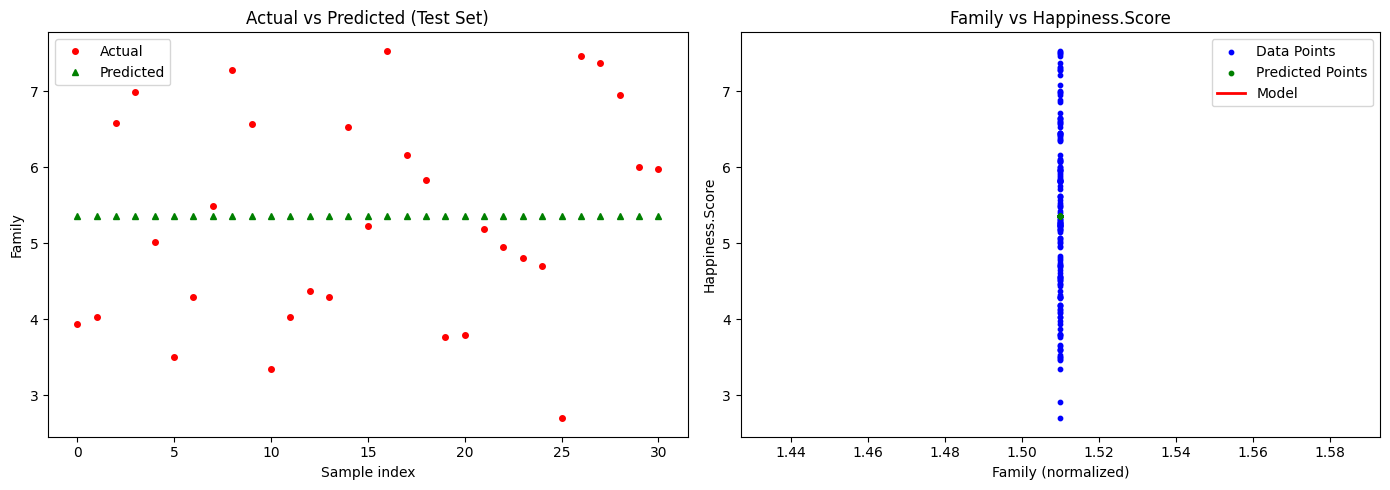

In [8]:
X_family = df['Family_normalized']
Y_family = df[target]
X_f_train, X_f_test, Y_f_train, Y_f_test = train_test_spliter(X_family, Y_family)

model = LinearRegression()
model.fit_one_features(X_f_train, Y_f_train)

predictions_family = model.predict(X_f_test)
MAE_family = mean_absolut_error(Y_family, predictions_family)
RMSE_family = root_mean_squared_error(Y_family, predictions_family)

print('MAE using only the family feature:', MAE_family)
print('RMSE using only the family feature:', RMSE_family)

w0 = model.intercept_
w1 = model.coef_[0]
x_f_min, x_f_max = min(X_f_train), max(X_f_train)
xref = [x_f_min + i * (x_f_max - x_f_min) / 1000 for i in range(1000)]
yref = [w0 + w1 * el for el in xref]

_, axes = plt.subplots(1, 2, figsize=(14, 5))

# actual vs predicted
axes[0].plot(Y_f_test, 'ro', markersize=4, label='Actual')
axes[0].plot(predictions_family, 'g^', markersize=4, label='Predicted')
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Family')
axes[0].set_title('Actual vs Predicted (Test Set)')
axes[0].legend()

# regression line
X_f_all = df['Family_normalized']
Y_f_all = df[target]

axes[1].scatter(X_f_all, Y_f_all, color='blue', label='Data Points', s=10)
axes[1].scatter(X_f_test, predictions_family, color='green', label='Predicted Points', s=10)
axes[1].plot(xref, yref, 'r-', linewidth=2, label='Model')
axes[1].set_xlabel('Family (normalized)')
axes[1].set_ylabel(target)
axes[1].set_title(f'Family vs {target}')
axes[1].legend()

plt.tight_layout()
plt.show()

MAE using only the GDP feature: 0.3289507944837413
RMSE using only the GDP feature: 0.8741088033864468
Regressor: F(x, w) = 3.347473512936107 + 3.8086566322021764 * x


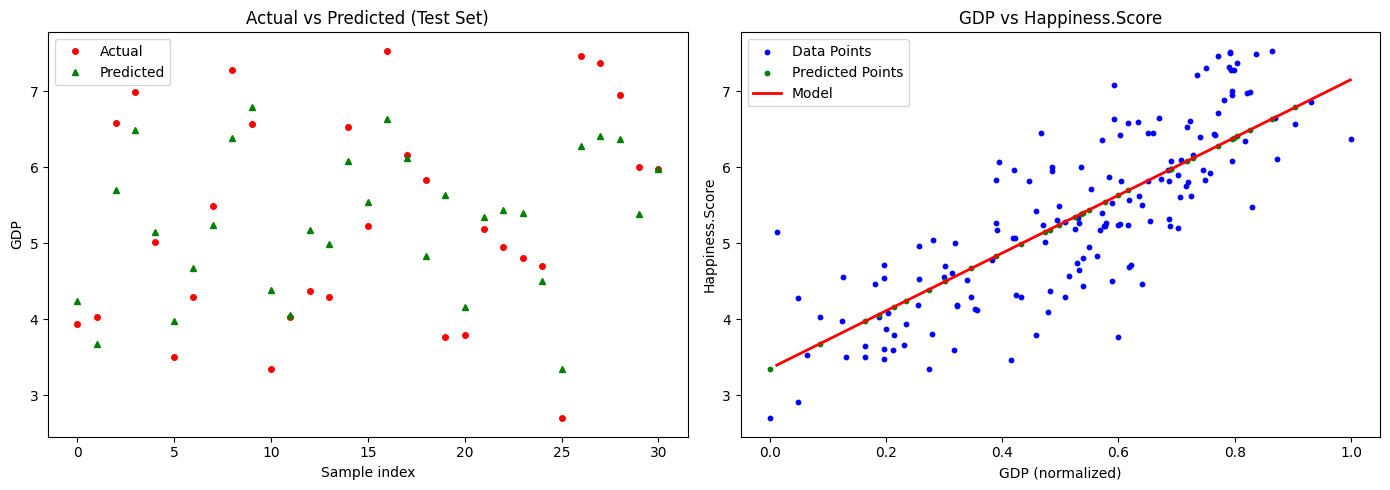

In [9]:
X_gdp = df['Economy..GDP.per.Capita._normalized']
Y_gdp = df[target]
X_gdp_train, X_gdp_test, Y_gdp_train, Y_gdp_test = train_test_spliter(X_gdp, Y_gdp)

model = LinearRegression()
model.fit_one_features(X_gdp_train, Y_gdp_train)

predictions_gdp = model.predict(X_gdp_test)
MAE_gdp = mean_absolut_error(Y_gdp, predictions_gdp)
RMSE_gdp = root_mean_squared_error(Y_gdp, predictions_gdp)

print('MAE using only the GDP feature:', MAE_gdp)
print('RMSE using only the GDP feature:', RMSE_gdp)

w0 = model.intercept_
w1 = model.coef_[0]

print(f'Regressor: F(x, w) = {w0} + {w1} * x')

x_gdp_min, x_gdp_max = min(X_gdp_train), max(X_gdp_train)
xref = [x_gdp_min + i * (x_gdp_max - x_gdp_min) / 1000 for i in range(1000)]
yref = [w0 + w1 * el for el in xref]

_, axes = plt.subplots(1, 2, figsize=(14, 5))

# actual vs predicted
axes[0].plot(Y_gdp_test, 'ro', markersize=4, label='Actual')
axes[0].plot(predictions_gdp, 'g^', markersize=4, label='Predicted')
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('GDP')
axes[0].set_title('Actual vs Predicted (Test Set)')
axes[0].legend()

# regression line
X_gdp_all = df['Economy..GDP.per.Capita._normalized']
Y_gdp_all = df[target]

axes[1].scatter(X_gdp_all, Y_gdp_all, color='blue', label='Data Points', s=10)
axes[1].scatter(X_gdp_test, predictions_gdp, color='green', label='Predicted Points', s=10)
axes[1].plot(xref, yref, 'r-', linewidth=2, label='Model')
axes[1].set_xlabel('GDP (normalized)')
axes[1].set_ylabel(target)
axes[1].set_title(f'GDP vs {target}')
axes[1].legend()

plt.tight_layout()
plt.show()

MAE using only {GDP, Freedom} features: 0.4963710891774348
RMSE using only {GDP, Freedom} features: 0.6501744116744838
Regressor: W = 2.581797100946443 + 3.351327997986138 * x + 1.6297270060362194 * x


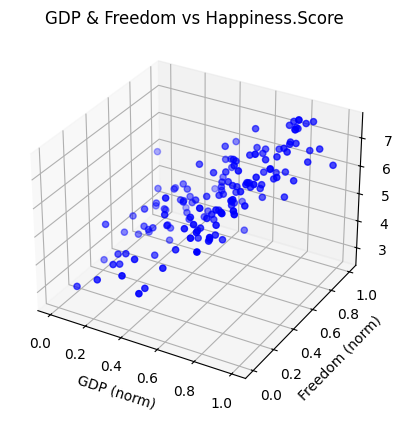

In [ ]:
X = list(zip(df['Economy..GDP.per.Capita._normalized'], df['Freedom_normalized']))
Y = df[target]

X_train, X_test, Y_train, Y_test = train_test_spliter(X, Y)

model = LinearRegression()
model.fit_two_feature(X_train, Y_train)

predictions = model.predict(X_test)
MAE_test = mean_absolut_error(Y_test, predictions)
RMSE_test = root_mean_squared_error(Y_test, predictions)
print('MAE using only {GDP, Freedom} features:', MAE_test)
print('RMSE using only {GDP, Freedom} features:', RMSE_test)

w_0 = model.intercept_
w_1, w_2 = model.coef_[0], model.coef_[1]
print(f'Regressor: W = {w_0} + {w_1} * x + {w_2} * x')

 # 3D scatter of all data points
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    df['Economy..GDP.per.Capita._normalized'],
    df['Freedom_normalized'],
    df[target],
    c='b', marker='o'
)
ax.set_xlabel('GDP (norm)')
ax.set_ylabel('Freedom (norm)')
ax.set_zlabel(target)
ax.set_title(f'GDP & Freedom vs {target}')
plt.show()